# Chapter 1.4: Embedding Fundamentals

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the connection between Word2Vec and recommendation embeddings
2. Implement Skip-gram with negative sampling from scratch
3. Understand co-occurrence statistics and PMI in the recommendation context
4. Train Item2Vec on synthetic purchase sequences
5. Visualize embeddings with t-SNE and PCA
6. Evaluate embedding quality using nearest neighbors and analogy tasks
7. Reason about when embedding-based methods are preferred over classical CF

## Prerequisites

- Chapter 1.3: Collaborative Filtering (MF, BPR)
- Basic understanding of neural network training (forward pass, backprop)
- PyTorch fundamentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part1/chapter_1.4_embeddings.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part1/chapter_1.4_embeddings.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter, defaultdict

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print("All imports successful!")

All imports successful!


## 1. From Word2Vec to Item2Vec

### Word2Vec Recap

Word2Vec learns dense vector representations of words from their context:

**Skip-gram**: Given a center word, predict context words.

$$
P(w_c \mid w_t) = \frac{\exp(\mathbf{v}_{w_c} \cdot \mathbf{v}_{w_t})}{\sum_{w \in V} \exp(\mathbf{v}_w \cdot \mathbf{v}_{w_t})}
$$

**CBOW**: Given context words, predict the center word.

### The Item2Vec Connection

| NLP | RecSys |
|---|---|
| Sentence | User session / purchase history |
| Word | Item |
| Word context window | Co-purchased / co-viewed items |
| Vocabulary | Item catalog |

Key insight from Barkan & Koenigstein (2016): **Items that co-occur in user sessions are like words that co-occur in sentences**.

$$
\text{Sentence: } [\text{The}, \text{cat}, \text{sat}, \text{on}, \text{the}, \text{mat}]
$$
$$
\text{Session: } [\text{iPhone}, \text{Case}, \text{Charger}, \text{AirPods}, \text{AppleCare}]
$$

In [2]:
# Generate synthetic purchase sequences with item categories
n_items = 200
n_categories = 8
n_sessions = 5000

# Assign items to categories
item_categories = np.random.randint(0, n_categories, n_items)
category_names = ['Electronics', 'Books', 'Clothing', 'Home', 'Sports', 'Food', 'Music', 'Movies']

# Items within the same category are more likely to co-occur
def generate_sessions(n_sessions, n_items, item_categories, 
                      session_len_range=(3, 10), intra_category_prob=0.7):
    """Generate purchase sessions where items in the same category co-occur more."""
    sessions = []
    item_popularity = np.random.power(0.3, n_items)
    item_popularity /= item_popularity.sum()
    
    for _ in range(n_sessions):
        session_len = np.random.randint(session_len_range[0], session_len_range[1] + 1)
        session = []
        
        # Pick first item based on popularity
        first_item = np.random.choice(n_items, p=item_popularity)
        session.append(first_item)
        main_category = item_categories[first_item]
        
        for _ in range(session_len - 1):
            if np.random.random() < intra_category_prob:
                # Pick from same category
                same_cat = np.where(item_categories == main_category)[0]
                # Filter out already in session
                available = [i for i in same_cat if i not in session]
                if available:
                    session.append(np.random.choice(available))
                else:
                    session.append(np.random.choice(n_items, p=item_popularity))
            else:
                session.append(np.random.choice(n_items, p=item_popularity))
        
        sessions.append(session)
    
    return sessions


sessions = generate_sessions(n_sessions, n_items, item_categories)

print(f"Generated {len(sessions)} sessions")
print(f"Session length range: {min(len(s) for s in sessions)}-{max(len(s) for s in sessions)}")
print(f"Average session length: {np.mean([len(s) for s in sessions]):.1f}")
print(f"\nSample session: {sessions[0]}")
print(f"Categories: {[category_names[item_categories[i]] for i in sessions[0]]}")

Generated 5000 sessions
Session length range: 3-10
Average session length: 6.5

Sample session: [39, 12, 191, 179, 199, 56, 40]
Categories: ['Clothing', 'Clothing', 'Clothing', 'Clothing', 'Clothing', 'Movies', 'Clothing']


## 2. Co-occurrence and PMI

Before training embeddings, let's understand the statistical foundation.

**Co-occurrence matrix** $C$: $C_{ij}$ = number of times items $i$ and $j$ appear in the same session.

**Pointwise Mutual Information (PMI)**:
$$
\text{PMI}(i, j) = \log \frac{P(i, j)}{P(i) \cdot P(j)} = \log \frac{C_{ij} \cdot |D|}{C_i \cdot C_j}
$$

> **💡 Concept:** Levy & Goldberg (2014) showed that Word2Vec's Skip-gram with negative sampling implicitly factorizes a shifted PMI matrix. This means Item2Vec is implicitly learning about item co-occurrence patterns!

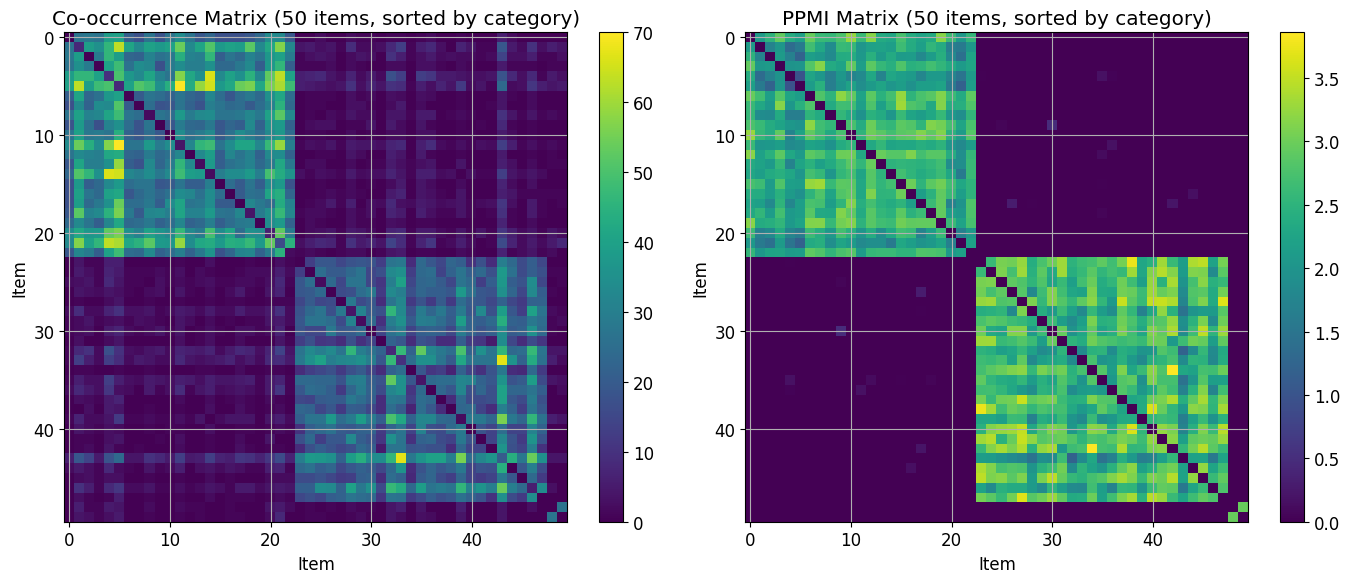

Notice the block-diagonal structure - items in the same category co-occur more!


In [3]:
# Build co-occurrence matrix
cooccurrence = np.zeros((n_items, n_items))
item_counts = np.zeros(n_items)

for session in sessions:
    for i in session:
        item_counts[i] += 1
    for idx_a in range(len(session)):
        for idx_b in range(idx_a + 1, len(session)):
            i, j = session[idx_a], session[idx_b]
            cooccurrence[i, j] += 1
            cooccurrence[j, i] += 1

# Compute PMI
total = cooccurrence.sum()
p_ij = cooccurrence / max(total, 1)
p_i = item_counts / max(item_counts.sum(), 1)
p_joint = np.outer(p_i, p_i)

# Avoid log(0)
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2(np.where(p_joint > 0, p_ij / p_joint, 1))
    pmi = np.nan_to_num(pmi, nan=0, posinf=0, neginf=0)

# Positive PMI (PPMI) - replace negative values with 0
ppmi = np.maximum(pmi, 0)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sort items by category for clearer visualization
sorted_idx = np.argsort(item_categories)

im0 = axes[0].imshow(cooccurrence[np.ix_(sorted_idx[:50], sorted_idx[:50])], 
                       cmap='viridis', aspect='auto')
axes[0].set_title('Co-occurrence Matrix (50 items, sorted by category)')
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Item')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ppmi[np.ix_(sorted_idx[:50], sorted_idx[:50])], 
                       cmap='viridis', aspect='auto')
axes[1].set_title('PPMI Matrix (50 items, sorted by category)')
axes[1].set_xlabel('Item')
axes[1].set_ylabel('Item')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("Notice the block-diagonal structure - items in the same category co-occur more!")

## 3. Skip-gram with Negative Sampling (SGNS)

The full softmax is expensive. Negative sampling approximates it:

$$
\mathcal{L} = -\log \sigma(\mathbf{v}_i \cdot \mathbf{v}_j) - \sum_{k=1}^{K} \mathbb{E}_{n \sim P_n} \log \sigma(-\mathbf{v}_i \cdot \mathbf{v}_n)
$$

where $K$ is the number of negative samples and $P_n(w) \propto f(w)^{3/4}$ is the noise distribution.

> **⚠️ Common Pitfall:** The noise distribution $P_n(w) \propto f(w)^{3/4}$ (the 3/4 power) is crucial. Using uniform sampling hurts quality because popular items dominate the gradient. The 3/4 power smooths the distribution to give rare items more weight as negatives.

In [4]:
class Item2Vec(nn.Module):
    """Item2Vec: Skip-gram with Negative Sampling for items."""
    
    def __init__(self, n_items, embedding_dim=32):
        super().__init__()
        self.center_emb = nn.Embedding(n_items, embedding_dim)
        self.context_emb = nn.Embedding(n_items, embedding_dim)
        
        # Xavier initialization
        nn.init.xavier_uniform_(self.center_emb.weight)
        nn.init.xavier_uniform_(self.context_emb.weight)
    
    def forward(self, center, context, negatives):
        """
        Args:
            center: (batch_size,) center item IDs
            context: (batch_size,) positive context item IDs
            negatives: (batch_size, n_neg) negative item IDs
        """
        center_vec = self.center_emb(center)        # (batch, dim)
        context_vec = self.context_emb(context)      # (batch, dim)
        neg_vecs = self.context_emb(negatives)       # (batch, n_neg, dim)
        
        # Positive score
        pos_score = (center_vec * context_vec).sum(dim=1)  # (batch,)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-10)
        
        # Negative scores
        neg_scores = torch.bmm(neg_vecs, center_vec.unsqueeze(2)).squeeze(2)  # (batch, n_neg)
        neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-10).sum(dim=1)
        
        return (pos_loss + neg_loss).mean()
    
    def get_embeddings(self):
        """Return item embeddings (average of center and context)."""
        return ((self.center_emb.weight.data + self.context_emb.weight.data) / 2).numpy()


def generate_skipgram_data(sessions, window_size=3, n_neg=5):
    """Generate skip-gram training pairs with negative sampling."""
    # Build noise distribution (frequency^0.75)
    item_freq = Counter()
    for session in sessions:
        item_freq.update(session)
    
    n_items = max(item_freq.keys()) + 1
    freq = np.zeros(n_items)
    for item, count in item_freq.items():
        freq[item] = count
    
    noise_dist = freq ** 0.75
    noise_dist /= noise_dist.sum()
    
    centers, contexts, negatives = [], [], []
    
    for session in sessions:
        for i, center in enumerate(session):
            # Context window
            start = max(0, i - window_size)
            end = min(len(session), i + window_size + 1)
            
            for j in range(start, end):
                if j == i:
                    continue
                context = session[j]
                # Sample negatives
                negs = np.random.choice(n_items, size=n_neg, p=noise_dist)
                
                centers.append(center)
                contexts.append(context)
                negatives.append(negs)
    
    return (torch.LongTensor(centers), 
            torch.LongTensor(contexts),
            torch.LongTensor(negatives))


print("Generating skip-gram training data...")
centers, contexts, negs = generate_skipgram_data(sessions, window_size=3, n_neg=5)
print(f"Training pairs: {len(centers):,}")

Generating skip-gram training data...


Training pairs: 135,438


/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78077/1340788392.py:75: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  torch.LongTensor(negatives))


Training Item2Vec...


  Epoch 5/15, Loss: 2.2255


  Epoch 10/15, Loss: 2.1690


  Epoch 15/15, Loss: 2.1560


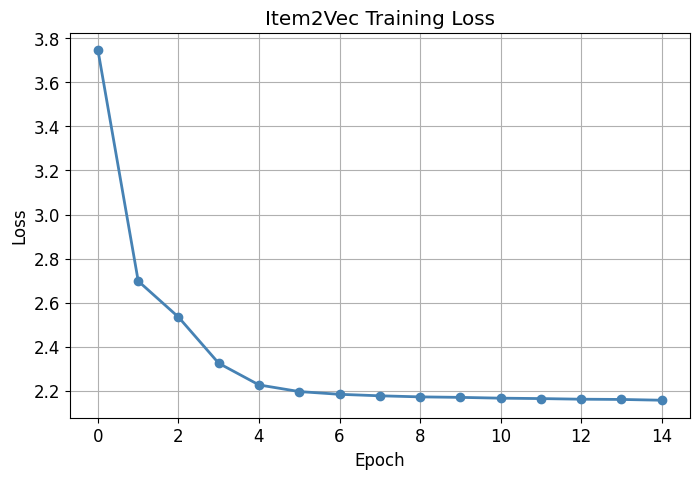

In [5]:
# Train Item2Vec
torch.manual_seed(42)
model = Item2Vec(n_items, embedding_dim=32)
optimizer = optim.Adam(model.parameters(), lr=0.003)

batch_size = 2048
n_epochs = 15
losses = []

print("Training Item2Vec...")
for epoch in range(n_epochs):
    # Shuffle
    perm = torch.randperm(len(centers))
    epoch_loss = 0
    n_batches = 0
    
    for start in range(0, len(centers), batch_size):
        end = min(start + batch_size, len(centers))
        idx = perm[start:end]
        
        loss = model(centers[idx], contexts[idx], negs[idx])
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(losses, linewidth=2, color='steelblue', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Item2Vec Training Loss')
plt.show()

## 4. Embedding Visualization

### PCA (Principal Component Analysis)
Linear dimensionality reduction. Fast but may miss non-linear structure.

### t-SNE
Non-linear embedding that preserves local neighborhoods. Better for visualization but slow.

$$
\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

where $p_{ij}$ captures similarity in the high-dimensional space and $q_{ij}$ in the 2D space.

/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


/var/folders/fm/hwpyrzvx207290wd3x3n9zgh0000gn/T/ipykernel_78077/2306161830.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_categories)


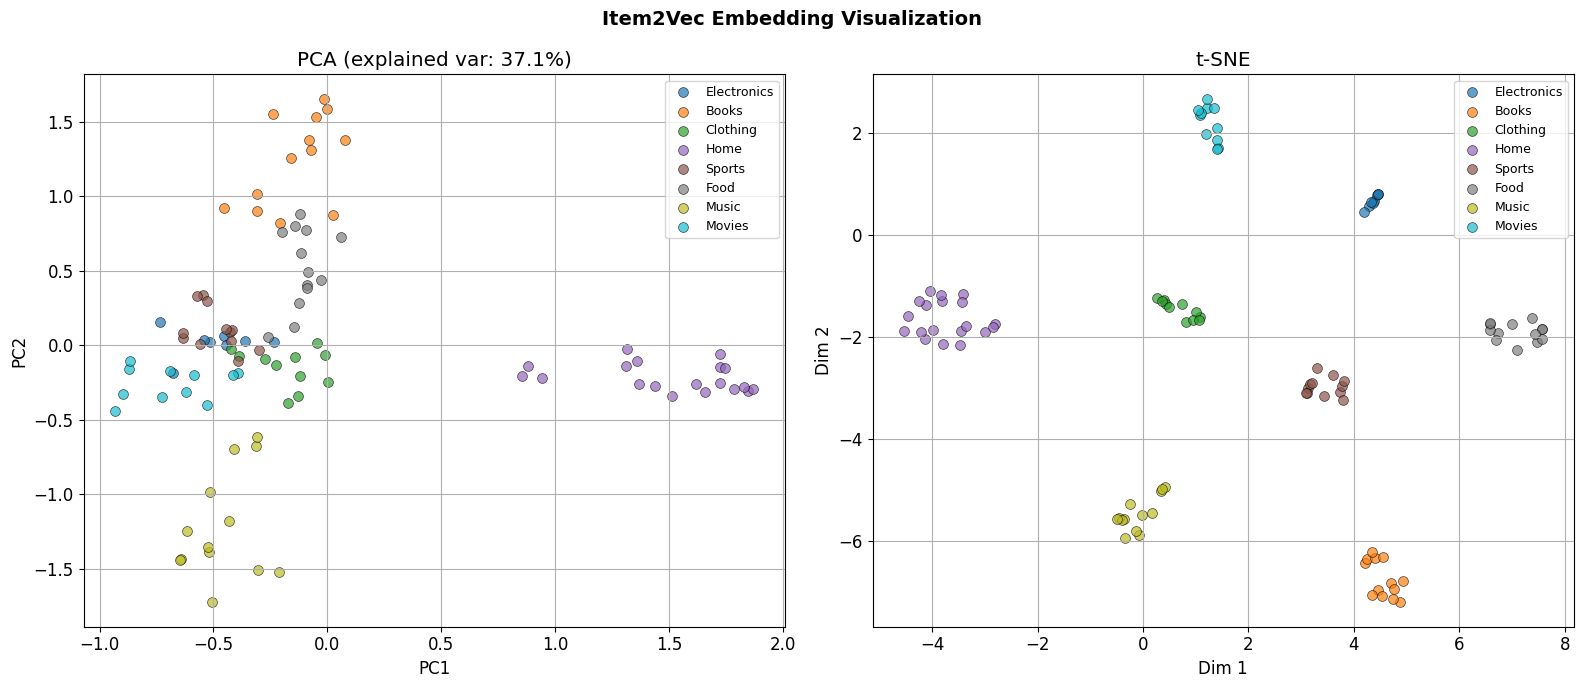

Items from the same category should cluster together if the embeddings are good.


In [6]:
# Get trained embeddings
embeddings = model.get_embeddings()

# Select items that have enough interactions for meaningful embeddings
active_items = np.where(item_counts > 10)[0]
if len(active_items) > 100:
    active_items = active_items[:100]

active_embeddings = embeddings[active_items]
active_categories = item_categories[active_items]

# PCA
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(active_embeddings)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(active_items) - 1))
emb_tsne = tsne.fit_transform(active_embeddings)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cmap = plt.cm.get_cmap('tab10', n_categories)

for cat_id in range(n_categories):
    mask = active_categories == cat_id
    if mask.sum() == 0:
        continue
    axes[0].scatter(emb_pca[mask, 0], emb_pca[mask, 1], 
                    c=[cmap(cat_id)], label=category_names[cat_id],
                    s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    axes[1].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                    c=[cmap(cat_id)], label=category_names[cat_id],
                    s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

axes[0].set_title(f'PCA (explained var: {pca.explained_variance_ratio_.sum():.1%})')
axes[0].legend(fontsize=9, loc='best')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].set_title('t-SNE')
axes[1].legend(fontsize=9, loc='best')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')

plt.suptitle('Item2Vec Embedding Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Items from the same category should cluster together if the embeddings are good.")

## 5. Embedding Quality Evaluation

### Nearest Neighbors
Find items most similar to a query item in embedding space.

### Category Coherence
Measure how often nearest neighbors share the same category as the query.

In [7]:
def cosine_similarity(a, b):
    """Compute cosine similarity between vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)


def find_nearest_neighbors(embeddings, query_idx, k=5):
    """Find k nearest neighbors by cosine similarity."""
    query = embeddings[query_idx]
    sims = np.array([cosine_similarity(query, embeddings[i]) 
                     for i in range(len(embeddings))])
    sims[query_idx] = -np.inf  # Exclude self
    top_k = np.argsort(sims)[-k:][::-1]
    return top_k, sims[top_k]


# Show nearest neighbors for sample items
print("Nearest Neighbors (by cosine similarity in embedding space):\n")
sample_items = [0, 10, 50, 100]
for item in sample_items:
    if item >= n_items:
        continue
    neighbors, sims = find_nearest_neighbors(embeddings, item, k=5)
    cat = category_names[item_categories[item]]
    print(f"Item {item} ({cat}):")
    for n, s in zip(neighbors, sims):
        n_cat = category_names[item_categories[n]]
        match = "Y" if item_categories[n] == item_categories[item] else "N"
        print(f"  -> Item {n} ({n_cat}), sim={s:.3f} [same_cat={match}]")
    print()

# Category coherence: what fraction of top-5 neighbors share the category?
coherence_scores = []
for item in range(n_items):
    if item_counts[item] < 5:
        continue
    neighbors, _ = find_nearest_neighbors(embeddings, item, k=5)
    same_cat = sum(1 for n in neighbors if item_categories[n] == item_categories[item])
    coherence_scores.append(same_cat / 5)

print(f"\nCategory Coherence @5: {np.mean(coherence_scores):.3f}")
print(f"(Random baseline: {1/n_categories:.3f})")

Nearest Neighbors (by cosine similarity in embedding space):

Item 0 (Music):
  -> Item 64 (Music), sim=0.958 [same_cat=Y]
  -> Item 8 (Music), sim=0.958 [same_cat=Y]
  -> Item 134 (Music), sim=0.945 [same_cat=Y]
  -> Item 193 (Music), sim=0.943 [same_cat=Y]
  -> Item 188 (Music), sim=0.935 [same_cat=Y]

Item 10 (Clothing):
  -> Item 191 (Clothing), sim=0.985 [same_cat=Y]
  -> Item 58 (Clothing), sim=0.976 [same_cat=Y]
  -> Item 183 (Clothing), sim=0.971 [same_cat=Y]
  -> Item 52 (Clothing), sim=0.970 [same_cat=Y]
  -> Item 150 (Clothing), sim=0.968 [same_cat=Y]

Item 50 (Music):
  -> Item 194 (Music), sim=0.918 [same_cat=Y]
  -> Item 109 (Music), sim=0.910 [same_cat=Y]
  -> Item 190 (Music), sim=0.906 [same_cat=Y]
  -> Item 188 (Music), sim=0.898 [same_cat=Y]
  -> Item 100 (Music), sim=0.897 [same_cat=Y]

Item 100 (Music):
  -> Item 3 (Music), sim=0.932 [same_cat=Y]
  -> Item 181 (Music), sim=0.926 [same_cat=Y]
  -> Item 114 (Music), sim=0.924 [same_cat=Y]
  -> Item 187 (Music), sim=0


Category Coherence @5: 1.000
(Random baseline: 0.125)


> **🔑 Pro Tip:** In practice, embedding quality is best evaluated by downstream task performance (e.g., recommendation accuracy), not just by visual clustering or nearest-neighbor coherence. But these qualitative checks are valuable for debugging and understanding.

## 6. Embedding Arithmetic (Analogy Tasks)

In Word2Vec: $\text{king} - \text{man} + \text{woman} \approx \text{queen}$

In RecSys: $\text{action\_movie\_1} - \text{action\_avg} + \text{comedy\_avg} \approx \text{comedy\_movies}$

Embedding Arithmetic (Analogy):

'Electronics' item 31 - Electronics centroid + Clothing centroid =
  -> Item 146 (Clothing), sim=0.962
  -> Item 13 (Clothing), sim=0.925
  -> Item 199 (Clothing), sim=0.921
  -> Item 151 (Clothing), sim=0.912
  -> Item 177 (Clothing), sim=0.910


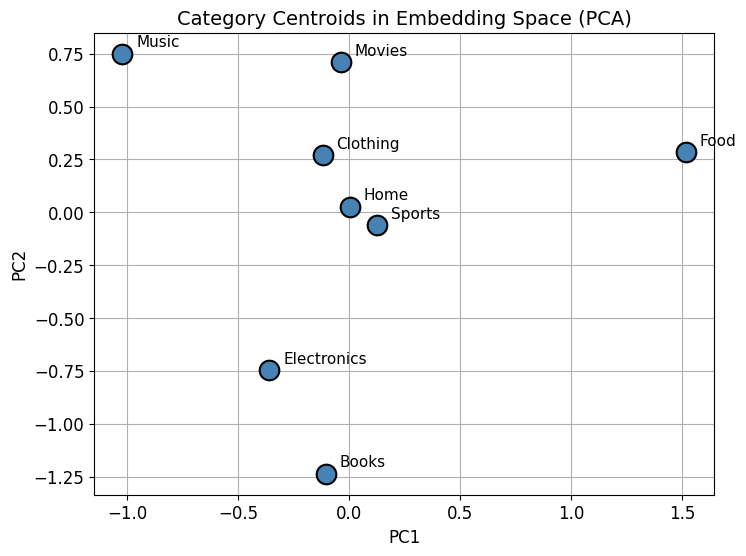

In [8]:
# Compute category centroids
category_centroids = {}
for cat in range(n_categories):
    cat_items = np.where(item_categories == cat)[0]
    if len(cat_items) > 0:
        category_centroids[cat] = embeddings[cat_items].mean(axis=0)

# Analogy: item_from_cat_A - centroid_A + centroid_B should be close to items in cat_B
print("Embedding Arithmetic (Analogy):\n")
cat_a, cat_b = 0, 2  # Electronics -> Clothing
items_a = np.where(item_categories == cat_a)[0]

if len(items_a) > 0 and cat_a in category_centroids and cat_b in category_centroids:
    source_item = items_a[0]
    # Analogy vector
    analogy_vec = embeddings[source_item] - category_centroids[cat_a] + category_centroids[cat_b]
    
    # Find nearest items to the analogy vector
    sims = np.array([cosine_similarity(analogy_vec, embeddings[i]) for i in range(n_items)])
    sims[source_item] = -np.inf
    top_5 = np.argsort(sims)[-5:][::-1]
    
    print(f"'{category_names[cat_a]}' item {source_item} "
          f"- {category_names[cat_a]} centroid + {category_names[cat_b]} centroid =")
    for idx in top_5:
        print(f"  -> Item {idx} ({category_names[item_categories[idx]]}), sim={sims[idx]:.3f}")

# Visualize category centroids
centroid_vecs = np.array([category_centroids[c] for c in range(n_categories) if c in category_centroids])
centroid_labels = [category_names[c] for c in range(n_categories) if c in category_centroids]

pca_centroids = PCA(n_components=2).fit_transform(centroid_vecs)

plt.figure(figsize=(8, 6))
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], s=200, c='steelblue', 
            edgecolors='black', linewidth=1.5, zorder=5)
for i, label in enumerate(centroid_labels):
    plt.annotate(label, (pca_centroids[i, 0], pca_centroids[i, 1]),
                 textcoords="offset points", xytext=(10, 5), fontsize=11)
plt.title('Category Centroids in Embedding Space (PCA)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

---

## Exercises

### 🏋️ Exercise 1: Train Item2Vec on Synthetic Purchase Sequences

Modify the data generation to create more complex patterns (e.g., cross-category bundles) and train Item2Vec.

In [9]:
# TODO: Create sessions with "bundle" patterns:
# - Electronics + Home (e.g., smart home setup)
# - Books + Music (e.g., cultural interests)
# - Sports + Food (e.g., fitness lifestyle)
#
# 1. Generate sessions where certain category pairs co-occur frequently
# 2. Train Item2Vec on these sessions
# 3. Verify the cross-category relationships appear in the embeddings
# 4. Visualize with t-SNE and check if bundle categories are close
pass

### 🏋️ Exercise 2: Compare Skip-gram vs CBOW

Implement CBOW (Continuous Bag of Words) version of Item2Vec and compare with Skip-gram.

In [10]:
class Item2Vec_CBOW(nn.Module):
    """CBOW version: predict center item from context items."""
    
    def __init__(self, n_items, embedding_dim=32):
        super().__init__()
        # TODO: Initialize embeddings
        pass
    
    def forward(self, context_items, center, negatives):
        """
        Args:
            context_items: (batch_size, context_size) context item IDs
            center: (batch_size,) center item IDs
            negatives: (batch_size, n_neg) negative item IDs
        """
        # TODO: Implement CBOW forward pass
        # 1. Average context embeddings
        # 2. Compute positive score with center item
        # 3. Compute negative scores
        # 4. Return loss
        pass


# TODO: Train CBOW model and compare embedding quality with Skip-gram
# Compare: category coherence, visualization, nearest neighbors

### 🏋️ Exercise 3: Window Size and Embedding Dimension Analysis

Study the effect of hyperparameters on embedding quality.

In [11]:
# TODO:
# 1. Train Item2Vec with window sizes: [1, 2, 3, 5, 10]
# 2. Train Item2Vec with embedding dimensions: [4, 8, 16, 32, 64, 128]
# 3. For each configuration, measure:
#    - Category coherence @5
#    - Training loss
# 4. Plot the results and identify optimal settings
# 5. Explain why very large/small windows and dimensions may hurt
pass

## Summary

In this notebook, we covered:

1. **Word2Vec to Item2Vec**: The direct mapping from NLP to RecSys
2. **Co-occurrence and PMI**: The statistical foundation behind embedding methods
3. **Skip-gram with Negative Sampling**: Efficient training of item embeddings
4. **Visualization**: PCA and t-SNE for understanding embedding spaces
5. **Evaluation**: Nearest neighbors, category coherence, and analogy tasks

### Key Takeaways

- Item embeddings capture co-occurrence patterns from user sessions
- The 3/4 power in the noise distribution is critical for quality
- Good embeddings cluster semantically similar items together
- Embeddings serve as the foundation for deep learning RecSys models

### Next Up

In **Chapter 1.5**, we'll learn the deep learning building blocks - MLP, attention, CNN, RNN - that operate on these embeddings.